In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit(
        "ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run "
        "jupyter lab)"
    )


DATA = data_dir()


# # Module 4 — Classification: Pass/Fail Decisions on the Production Line
#
# **Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**
#
# - *UCI SECOM* — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305
#   - Source: https://archive.ics.uci.edu/dataset/179/secom — License: CC BY 4.0
#
# ไฟล์: `datasets/secom.zip` (official UCI zip ไม่แก้ไข — ข้างในมี `secom.data`, `secom_labels.data`, `secom.names`)
#
# โมดูลนี้เปลี่ยนคำถามจาก Module 3: ไม่ถาม "ค่าจะออกเท่าไร" แต่ถาม **"ชิ้นงานชิ้นนี้ผ่านหรือ fail"** เราจะใช้ข้อมูลจริงจากสายผลิตเซมิคอนดักเตอร์ (เซนเซอร์/probe 590 ช่องต่อชิ้น) เรียนรู้สี่โมเดล classification และเห็นกับดักสองชั้น: **accuracy หลอกตอนคลาสไม่สมดุล** และ **threshold ของการตัดสิน ≈ tolerance limit** ที่เมโทรโลยีคุ้นเคย

# ## 1. อ่านข้อมูลสายผลิตจริง — SECOM
#
# ไฟล์ `.data` ไม่ใช่ CSV มีหัว — เป็นตัวเลขคั่นด้วยช่องว่าง อ่านจาก zip ตรง ๆ แล้วตั้งชื่อคอลัมน์เอง:
#
# - `secom.data` — 1,567 แถว × 590 features (ค่าที่วัดจากเซนเซอร์/probe บนสายผลิต)
# - `secom_labels.data` — label (`-1` = PASS, `+1` = FAIL) กับ timestamp (ทำให้รู้ว่าแถวเรียงตามลำดับการผลิต)
# - ทั้งสองไฟล์ **เรียงแถวตรงกัน** — join ด้วยลำดับแถว

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)


In [2]:
import io  # noqa: E402
import zipfile  # noqa: E402
import polars as pl  # noqa: E402
import numpy as np  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(
        io.BytesIO(z.read("secom.data")),
        separator=" ",
        has_header=False,
        new_columns=[f"feature_{i}" for i in range(1, 591)],
        schema_overrides=[pl.Float64] * 590,
        null_values="NaN",
    )
    lab = pl.read_csv(
        io.BytesIO(z.read("secom_labels.data")),
        separator=" ",
        quote_char='"',
        has_header=False,
        new_columns=["label", "timestamp"],
    )

secom = feats.with_columns(lab["label"].alias("label"))
n = len(secom)
print(f"shape = {secom.shape[0]} แถว × {secom.shape[1] - 1} features + label")

n_pass = int((secom["label"] == -1).sum())
n_fail = int((secom["label"] == 1).sum())
print(
    f"PASS (-1) = {n_pass}  |  FAIL (+1) = {n_fail}  ({n_fail / n * 100:.1f}%)"
)

shape = 1567 แถว × 590 features + label
PASS (-1) = 1463  |  FAIL (+1) = 104  (6.6%)


# ### ความหนาแน่นของค่าหาย (NaN density)
#
# เซนเซอร์สายผลิตจริงพัง/ออฟไลน์บ่อย — ตรวจว่าข้อมูลหายกี่เปอร์เซ็นต์ และ feature ไหนหายหนักสุด

In [3]:
miss = (
    secom.select(pl.exclude("label").null_count())
    .transpose(include_header=True, header_name="feature")
    .rename({"column_0": "n_missing"})
    .with_columns(pct_missing=(pl.col("n_missing") / n * 100).round(1))
    .sort("n_missing", descending=True)
)

total_missing = int(miss["n_missing"].sum())
total_cells = n * 590
print(
    f"ค่าหายรวม {total_missing:,} / {total_cells:,} เซลล์ = "
    f"{total_missing / total_cells * 100:.2f}%"
)
print(
    f"feature ที่มีค่าหายอย่างน้อย 1 ค่า: "
    f"{int((miss['n_missing'] > 0).sum())} / 590"
)
print("\nTop 10 feature ที่หายหนักสุด:")
print(miss.head(10))


ค่าหายรวม 41,951 / 924,530 เซลล์ = 4.54%
feature ที่มีค่าหายอย่างน้อย 1 ค่า: 538 / 590

Top 10 feature ที่หายหนักสุด:
shape: (10, 3)
┌─────────────┬───────────┬─────────────┐
│ feature     ┆ n_missing ┆ pct_missing │
│ ---         ┆ ---       ┆ ---         │
│ str         ┆ u32       ┆ f64         │
╞═════════════╪═══════════╪═════════════╡
│ feature_158 ┆ 1429      ┆ 91.2        │
│ feature_159 ┆ 1429      ┆ 91.2        │
│ feature_293 ┆ 1429      ┆ 91.2        │
│ feature_294 ┆ 1429      ┆ 91.2        │
│ feature_86  ┆ 1341      ┆ 85.6        │
│ feature_221 ┆ 1341      ┆ 85.6        │
│ feature_359 ┆ 1341      ┆ 85.6        │
│ feature_493 ┆ 1341      ┆ 85.6        │
│ feature_110 ┆ 1018      ┆ 65.0        │
│ feature_111 ┆ 1018      ┆ 65.0        │
└─────────────┴───────────┴─────────────┘


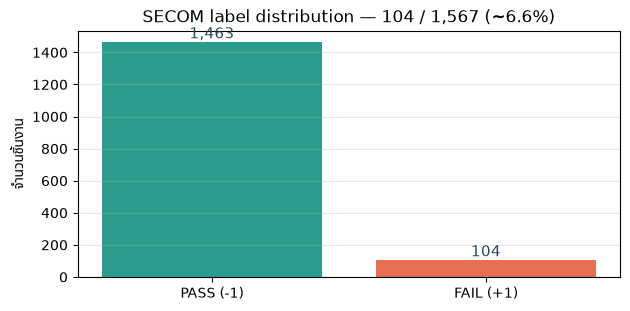

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(
    ["PASS (-1)", "FAIL (+1)"], [n_pass, n_fail], color=["#2a9d8f", "#e76f51"]
)
for i, v in enumerate([n_pass, n_fail]):
    ax.text(i, v + 25, f"{v:,}", ha="center", color="#264653", fontsize=11)
ax.set_ylabel("จำนวนชิ้นงาน")
ax.set_title("SECOM label distribution — 104 / 1,567 (~6.6%)")
ax.grid(alpha=0.3, axis="y")
plt.show()


# **สิ่งที่เห็น:** ของ fail มีแค่ 104 ชิ้นจาก 1,567 (~6.6%) — คลาสไม่สมดุลรุนแรง และค่าหาย ~4.5% ของทุกเซลล์ (บาง feature หายถึง 91%) ทั้งสองปัญหาจะกำหนดทั้งวิธีเทรนและวิธีวัดผลตลอดโมดูล

# ## 2. กับดัก accuracy — ตัวเลข 93.4% ที่ไม่ได้แปลว่าเก่ง
#
# ถ้าโมเดลตอบ "PASS" ทุกชิ้นโดยไม่คิดอะไรเลย จะได้ accuracy เท่ากับสัดส่วนคลาส majority = 1463/1567 ≈ **93.4%** — `DummyClassifier` ของ scikit-learn คือโมเดลจำลองแบบนี้ ใช้เป็น baseline เช็กความซื่อสัตย์ของตัวเลข

In [5]:
from sklearn.dummy import DummyClassifier  # noqa: E402

X = secom.drop("label")
y = secom["label"]

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X, y)  # ชี้คลาส majority โดยไม่ดู feature เลย
print(f"dummy accuracy (ทั้ง dataset) = {dummy.score(X, y):.4f}")
print(
    f"dummy ทำนาย FAIL กี่ชิ้น: {
        int((dummy.predict(X) == 1).sum())
    } ชิ้น — จากของจริง {n_fail} ชิ้น"
)


dummy accuracy (ทั้ง dataset) = 0.9336
dummy ทำนาย FAIL กี่ชิ้น: 0 ชิ้น — จากของจริง 104 ชิ้น


# **สิ่งที่เห็น:** โมเดลที่ "โง่ที่สุดในโลก" ก็ได้ accuracy 93.4% เพราะของดีมีเยอะ — แต่จับ fail ได้ **ศูนย์** ชิ้น ในงาน QC ของ fail คือสิ่งที่เราต้องการจับ
#
# **กฎของโมดูลนี้:** accuracy เทียบกับ base rate เสมอ ถ้าโมเดลได้ accuracy ใกล้ 93–95% ให้ถามต่อว่า "แล้วจับ fail ได้กี่ตัว" (การวัดแบบถี่ถ้วน — confusion matrix, precision/recall — คือหัวข้อของ Module 5)

# ## 3. Time-based split — ข้อมูลผลิตมาเป็นลำดับ แบ่งด้วยเวลา ไม่ใช่สุ่ม
#
# คอลัมน์ timestamp พิสูจน์ว่าแถวเรียงตามลำดับการผลิต (ก.ค. → ต.ค. 2008) ถ้าแบ่ง train/test แบบสุ่ม ชิ้นที่ผลิตติดกัน (เงื่อนไขสายผลิตใกล้เคียงกันมาก) จะหลุดไปคนละฝั่ง — test จึง "เห็นอดีตตัวเอง" และให้คะแนนฟุ่มเฟือย
#
# ในงานจริง โมเดลต้องตัดสิน **ชิ้นถัดไปที่ผลิตออกมา** — เราจึงแบ่งเหมือนเวลาจริง: 80% แรกเทรน, 20% ท้ายทดสอบ

In [6]:
ts = lab["timestamp"].str.strptime(
    pl.Datetime, format="%d/%m/%Y %H:%M:%S", strict=False
)
secom = secom.with_columns(ts.alias("ts"))

n_train = int(n * 0.8)
train, test = secom.head(n_train), secom.tail(n - n_train)

print(
    f"train: {len(train)} แถว  เวลา {train['ts'].min()} → {
        train['ts'].max()
    }  |  FAIL {int((train['label'] == 1).sum())}"
)
print(
    f"test : {len(test)} แถว  เวลา {test['ts'].min()} → {
        test['ts'].max()
    }  |  FAIL {int((test['label'] == 1).sum())}"
)


train: 1253 แถว  เวลา 2008-07-19 11:55:00 → 2008-10-02 19:25:00  |  FAIL 87
test : 314 แถว  เวลา 2008-10-02 20:54:00 → 2008-10-17 06:07:00  |  FAIL 17


# แบบนี้เลวร้ายกว่า random split เสมอในแง่ "ตัวเลขสวย" — นั่นแหละคือจุดประสงค์: ตัวเลขที่ได้คือตัวเลขที่โมเดลจะเจอจริงตอนขึ้นสายผลิต (ข้อมูลช่วงหลัง drift ไปจากช่วงต้น)

# ## 4. Preprocessing — median imputation + StandardScaler ใน Pipeline
#
# ใช้เครื่องมือจาก Day 1: เติมค่าหายด้วย **median** (ทน outlier กว่า mean) แล้ว **scale** ให้ทุก feature อยู่สเกลเดียวกัน — จัดทั้งหมดใน `Pipeline` เพื่อให้ imputer/scaler เรียน **จาก train เท่านั้น** (กัน leakage ด้วยโครงสร้าง)

feature = 590 คอลัมน์เซนเซอร์เท่านั้น (label คือคำตอบ, ts ใช้แค่พิสูจน์ลำดับการผลิต)

เรียน median/mean/std จาก train เท่านั้น


In [7]:
from sklearn.pipeline import Pipeline  # noqa: E402
from sklearn.impute import SimpleImputer  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

preprocess = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)

X_train = train.drop("label", "ts")
X_test = test.drop("label", "ts")

prep = preprocess.fit(X_train)
Xt = prep.transform(X_train)

print(
    f"shape หลังแปลง = {Xt.shape}, ค่าหายคงเหลือ = {int(np.isnan(Xt).sum())}")
print(
    f"หลัง scale: mean เฉลี่ยทุกคอลัมน์ = {Xt.mean():.4f}, std เฉลี่ย = "
    f"{Xt.std():.4f}"
)
print(
    f"median ที่เรียนได้ 5 ค่าแรก: {
        np.round(prep.named_steps['impute'].statistics_[:5], 3)
    }"
)

shape หลังแปลง = (1253, 590), ค่าหายคงเหลือ = 0
หลัง scale: mean เฉลี่ยทุกคอลัมน์ = 0.0000, std เฉลี่ย = 0.8906
median ที่เรียนได้ 5 ค่าแรก: [3.012090e+03 2.498840e+03 2.200133e+03 1.288086e+03 1.298000e+00]


# ต่อจากนี้ทุกโมเดลจะถูกห่อด้วย pipeline `impute → scale → model` เดียวกัน เพื่อให้เทียบกันได้ยุติธรรมและไม่มี leakage

# ## 5. สี่โมเดล — logistic, SVM, random forest, XGBoost
#
# สามตัวแรกใช้ `class_weight="balanced"` เพื่อบอกโมเดลว่า "ชิ้น fail หนึ่งชิ้นสำคัญกว่าชิ้น pass หลายเท่า" (scikit-learn จะให้น้ำหนักแก่คลาสส่วนน้อยโดยอัตโนมัติ) XGBoost ทำสิ่งเดียวกันด้วย `scale_pos_weight = n_neg / n_pos` — และ XGBoost ต้องการ label 0/1 เราจึง map `-1/+1 → 0/1` ก่อน
#
# (SVC ไม่มี `predict_proba` ตรง ๆ — ห่อด้วย `CalibratedClassifierCV` เพื่อได้ probability ที่เทียบกับตัวอื่นได้)

In [8]:
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.svm import SVC  # noqa: E402
from sklearn.calibration import CalibratedClassifierCV  # noqa: E402
from sklearn.ensemble import RandomForestClassifier  # noqa: E402
from xgboost import XGBClassifier  # noqa: E402

n_pos = int((train["label"] == 1).sum())
n_neg = len(train) - n_pos
spw = n_neg / n_pos
n_fail_test = int((test["label"] == 1).sum())
print(
    f"train: n_neg = {n_neg}, n_pos = {n_pos} → scale_pos_weight = {spw:.2f}"
)


def make_pipe(model):
    return Pipeline(
        [
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", model),
        ]
    )


models = {
    "Logistic (balanced)": make_pipe(
        LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=42
        )
    ),
    "SVM rbf (balanced)": make_pipe(
        CalibratedClassifierCV(
            SVC(kernel="rbf", class_weight="balanced", random_state=42),
            ensemble=False,
        )
    ),
    "RandomForest": make_pipe(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )
    ),
    "XGBoost": make_pipe(
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=5,
            scale_pos_weight=spw,
            random_state=42,
            eval_metric="logloss",
        )
    ),
}

y01_train = (train["label"] == 1).cast(pl.Int64)  # XGBoost ต้องการ 0/1
y01_test = (test["label"] == 1).cast(pl.Int64)


train: n_neg = 1166, n_pos = 87 → scale_pos_weight = 13.40


fail อยู่ที่ค่า 1 ทั้งสองระบบ label

In [9]:
rows = []
for name, model in models.items():
    yt = y01_train if name == "XGBoost" else train["label"]
    ye = y01_test if name == "XGBoost" else test["label"]
    model.fit(X_train, yt)
    acc_tr = model.score(X_train, yt)
    acc_te = model.score(X_test, ye)
    pred = model.predict(X_test)
    lab_true = test["label"].to_numpy()
    flagged = int((pred == 1).sum())
    caught = int(((pred == 1) & (lab_true == 1)).sum())
    fa = int(((pred == 1) & (lab_true == -1)).sum())
    rows.append(
        {
            "model": name,
            "acc_train": round(acc_tr, 4),
            "acc_test": round(acc_te, 4),
            "ตัดสิน FAIL": flagged,
            "จับ FAIL ได้": f"{caught}/{n_fail_test}",
            "false alarm": fa,
        }
    )
    models[name] = model

dummy_acc_test = int((test["label"] == -1).sum()) / len(test)
summary = pl.DataFrame(rows)
print(f"dummy baseline (ตอบ PASS ทุกชิ้น): acc_test = {dummy_acc_test:.4f}")
summary

dummy baseline (ตอบ PASS ทุกชิ้น): acc_test = 0.9459


model,acc_train,acc_test,ตัดสิน FAIL,จับ FAIL ได้,false alarm
str,f64,f64,i64,str,i64
"""Logistic (balanced)""",0.9816,0.9013,20,"""3/17""",17
"""SVM rbf (balanced)""",0.9306,0.9459,0,"""0/17""",0
"""RandomForest""",1.0,0.9459,0,"""0/17""",0
"""XGBoost""",1.0,0.9459,0,"""0/17""",0


# **อ่านตารางอย่างตื่นตัว:**
# - RandomForest กับ XGBoost ได้ acc_test = 0.9459 **เท่ากับ dummy เป๊ะ** — เพราะมันตอบ PASS ทุกชิ้น (จับ FAIL ได้ 0) accuracy สูงทั้งที่โมเดลไม่ได้ทำงาน — กับดักข้อ 2 ซ้ำอีกรอบ
# - Logistic (balanced) ยอมเสีย accuracy (0.9013 < 0.9459) เพื่อแลกการจับ FAIL ได้จริง — นี่คือ trade-off ของ `class_weight`
# - `class_weight="balanced"` ทำให้ probability ที่ได้ **ไม่ calibrated** (เบ้ขึ้นฝั่ง fail) — ดูได้จากตารางด้านล่าง

แอบดู predict_proba — โมเดลไม่ได้ตอบแค่ pass/fail แต่ให้ "ความเชื่อ" ด้วย


In [10]:
peek = pl.DataFrame(
    {
        "label จริง (test 6 แถวแรก)": test["label"].head(6),
        **{
            name: np.round(m.predict_proba(X_test)[:6, 1], 3)
            for name, m in models.items()
        },
    }
)
peek

label จริง (test 6 แถวแรก),Logistic (balanced),SVM rbf (balanced),RandomForest,XGBoost
i64,f64,f64,f64,f32
-1,0.001,0.065,0.113,0.003
1,0.022,0.082,0.07,0.007
-1,0.245,0.06,0.07,0.003
-1,0.988,0.068,0.067,0.081
-1,0.983,0.071,0.053,0.005
-1,0.0,0.102,0.033,0.001


# ทุกโมเดลให้ค่าในช่วง [0, 1] แทนความน่าจะเป็นที่ชิ้นนั้น fail — คอลัมน์ไหนสูงกว่าแปลว่า "โมเดลเชื่อมากขึ้นว่าชิ้นนี้เสีย" ค่าไม่เท่ากันข้ามโมเดล (เช่น SVM คืนช่วงแคบ ๆ ~0.05–0.11) เพราะแต่ละตัว "นิยาม" probability ของตัวเองต่างกัน — จุดนี้สำคัญตอนเลือก threshold ในข้อถัดไป

# ## 6. Threshold — "tolerance limit" ของการตัดสิน
#
# โมเดลให้ probability แต่โรงงานต้องการคำตอบ pass/fail เส้นแบ่งคือ **threshold t**: `P(fail) ≥ t → ตัดสิน FAIL`
#
# ที่ t = 0.5 คือ default ของ scikit-learn — แต่เราเลือกเองได้ เหมือนการตั้ง tolerance limit ของการตัดสิน: **ลด t ลง = จับ fail ได้มากขึ้น (recall สูงขึ้น) แต่ตัดของดีทิ้งมากขึ้น (false alarm)**

In [11]:
logit = models["Logistic (balanced)"]
p_fail_test = logit.predict_proba(X_test)[:, 1]
lab_true = test["label"].to_numpy()

thr_rows = []
for thr in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    flagged = p_fail_test >= thr
    caught = int((flagged & (lab_true == 1)).sum())
    fa = int((flagged & (lab_true == -1)).sum())
    thr_rows.append(
        {
            "threshold": thr,
            "ตัดสิน FAIL (ชิ้น)": int(flagged.sum()),
            "จับ FAIL ได้": f"{caught}/{n_fail_test}",
            "recall": round(caught / n_fail_test, 2),
            "false alarm (ตัดของดีทิ้ง)": fa,
        }
    )
pl.DataFrame(thr_rows)


threshold,ตัดสิน FAIL (ชิ้น),จับ FAIL ได้,recall,false alarm (ตัดของดีทิ้ง)
f64,i64,str,f64,i64
0.05,40,"""4/17""",0.24,36
0.1,33,"""4/17""",0.24,29
0.2,27,"""3/17""",0.18,24
0.3,24,"""3/17""",0.18,21
0.5,20,"""3/17""",0.18,17
0.7,15,"""3/17""",0.18,12
0.9,10,"""2/17""",0.12,8


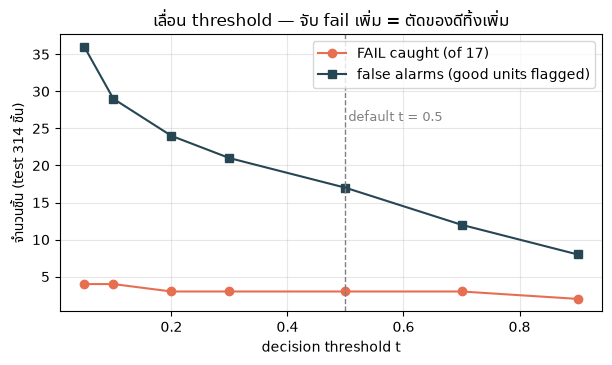

In [12]:
thrs = np.array([r["threshold"] for r in thr_rows])
caughts = np.array([int(r["จับ FAIL ได้"].split("/")[0]) for r in thr_rows])
fas = np.array([r["false alarm (ตัดของดีทิ้ง)"] for r in thr_rows])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(
    thrs, caughts, marker="o", color="#e76f51", label="FAIL caught (of 17)"
)
ax.plot(
    thrs,
    fas,
    marker="s",
    color="#264653",
    label="false alarms (good units flagged)",
)
ax.axvline(0.5, color="gray", ls="--", lw=1)
ax.text(0.505, 26, "default t = 0.5", color="gray", fontsize=9)
ax.set_xlabel("decision threshold t")
ax.set_ylabel("จำนวนชิ้น (test 314 ชิ้น)")
ax.set_title("เลื่อน threshold — จับ fail เพิ่ม = ตัดของดีทิ้งเพิ่ม")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


# **สิ่งที่เห็น:** ลด threshold จาก 0.5 → 0.05 จับ fail เพิ่มจาก 3/17 เป็น 4/17 แต่ false alarm พุ่งจาก 17 เป็น 36 — เส้นสองเส้นนี้ **แลกกันตลอด** ไม่มี threshold ที่ชนะทั้งสองฝั่ง
#
# การเลือก t จึงเป็น **การตัดสินใจเชิงต้นทุน** ไม่ใช่การหาค่าที่ "ถูก": ถ้าของเสียหลุดไปถึงลูกค้าแพงกว่าการ rework ของดีหลายเท่า — กด t ลง (ยอม false alarm เยอะ) การวัดผลอย่างถี่ถ้วน (precision/recall, ROC — แลกกันอย่างเป็นระบบ) คือหัวข้อของ **Module 5**

# ## 7. Feature importance แวบเดียว — ตัวไหนขับเคลื่อนการตัดสิน
#
# RandomForest รายงานได้ว่า feature ไหนถูกใช้แยก pass/fail มากที่สุด — ดู 15 อันดับแรกเป็น "จุดเริ่มต้นของการไล่สายผลิต" ไม่ใช่คำตอบสุดท้าย

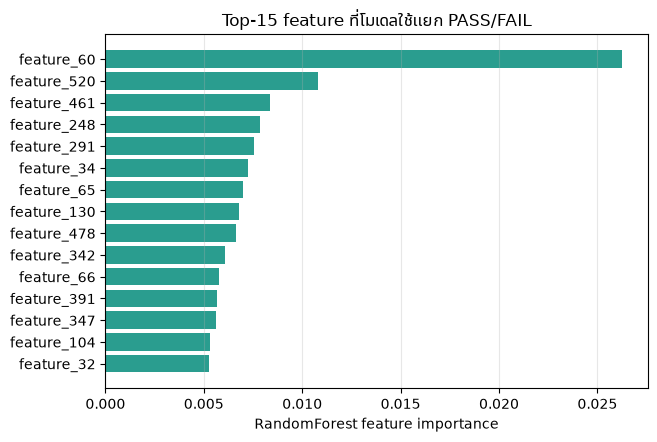

top 5: ['feature_60 (0.0263)', 'feature_520 (0.0108)', 'feature_461 (0.0083)', 'feature_248 (0.0079)', 'feature_291 (0.0075)']


In [13]:
rf = models["RandomForest"]
imp = rf.named_steps["model"].feature_importances_
top = np.argsort(imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(
    [f"feature_{i + 1}" for i in top][::-1], imp[top][::-1], color="#2a9d8f"
)
ax.set_xlabel("RandomForest feature importance")
ax.set_title("Top-15 feature ที่โมเดลใช้แยก PASS/FAIL")
ax.grid(alpha=0.3, axis="x")
plt.show()

print("top 5:", [f"feature_{i + 1} ({imp[i]:.4f})" for i in top[:5]])


# **สังเกตสองข้อ:**
# 1. ไม่มี feature ใดเด่นเด็ดขาด (ตัวนำอยู่ที่ ~0.026 จาก 1.0 รวมทั้ง 590 ตัว) — สัญญาณของ fail กระจายอยู่หลายเซนเซอร์ร่วมกัน ไม่ได้อยู่ที่ probe เดียว
# 2. **importance ≠ causation** — feature ที่ถูกใช้มากอาจเป็นแค่ตัวแทน (proxy) ของเวลา/ดริฟต์ของสายผลิต ไม่ใช่สาเหตุของความเสีย การสรุป "เซนเซอร์นี้ทำให้ของเสีย" ต้องยืนยันด้วยการทดลองจริง ไม่ใช่ดูแค่ importance
#
# อีกจุดที่ควรจำ: importance ของ RF ไม่บอกทิศทาง (สูงขึ้น = ดีหรือร้าย?) — ต่างจากสัมประสิทธิ์ของ logistic ที่มีเครื่องหมายบวก/ลบ

# ## 8. สรุปโมดูล
#
# - **SECOM** = ข้อมูลสายผลิตจริง 1,567 ชิ้น × 590 เซนเซอร์ มีค่าหาย ~4.5% และ fail แค่ 6.6% — ปัญหาจริงของ QC คือความไม่สมดุล
# - **accuracy หลอก**: dummy ตอบ PASS ทุกชิ้นได้ 93.4% — ของ fail คือสิ่งที่ต้องจับ จึงต้องดู "จับ fail ได้กี่ตัว" เสมอ
# - **แบ่งด้วยเวลา** สำหรับข้อมูลผลิต — random split ให้ตัวเลขสวยเกินจริง
# - Pipeline `median impute → StandardScaler → model` + `class_weight`/`scale_pos_weight` จัดการค่าหายและความไม่สมดุล
# - โมเดลให้ **probability** ผ่าน `predict_proba` — การตัดสิน pass/fail เกิดที่ **threshold** ซึ่งทำหน้าที่เหมือน tolerance limit: ลดลง = จับ fail เพิ่ม = ตัดของดีทิ้งเพิ่ม
# - feature importance เป็นจุดเริ่มการไล่หาสาเหตุ ไม่ใช่หลักฐานความเป็นสาเหตุ
#
# ต่อไป — **Module 5** จะวัด classifier อย่างซื่อสัตย์: confusion matrix, precision/recall, ROC-AUC/PR-AUC บน dataset เดียวกันนี้